# Generative Adversarial Networks

A GAN learns to sample from a data distribution $p_{\text{data}}$ by training **two** networks against each other:

- **Generator** $G_\theta(z)$ maps random noise $z \sim \mathcal{N}(0, I)$ to a sample $\hat{x}$.
- **Discriminator** (or **Critic**) $D_\phi(x)$ scores whether $x$ looks real.

The classic Goodfellow (2014) objective is the *minimax* game
$$\min_\theta \max_\phi \; \mathbb{E}_{x\sim p_{\text{data}}}[\log D_\phi(x)] + \mathbb{E}_{z\sim p_z}[\log(1-D_\phi(G_\theta(z)))].$$

We never see $p_{\text{data}}$ explicitly — only samples — yet the equilibrium of this game is $G_\#p_z = p_{\text{data}}$. Beautiful. Also notoriously hard to train.

**This tutorial.** We use a 2D toy distribution (25 Gaussians on a 5×5 grid) so we can *see* exactly what each network is doing at every step. We will:
1. Train a vanilla GAN and watch it mode-collapse.
2. Switch to a **WGAN-GP** (Wasserstein loss + gradient penalty) and watch it converge to all 25 modes.
3. Visualize the discriminator/critic's decision surface throughout training — the most informative diagnostic you have.

#### [1] [Goodfellow et al. 2014](https://arxiv.org/abs/1406.2661) — original GAN paper
#### [2] [Arjovsky et al. 2017](https://arxiv.org/abs/1701.07875) — Wasserstein GAN
#### [3] [Gulrajani et al. 2017](https://arxiv.org/abs/1704.00028) — WGAN-GP
#### [4] [Lilian Weng's GAN blog post](https://lilianweng.github.io/posts/2017-08-20-gan/) — extended reading

## Preamble

In [40]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

plt.rcParams['figure.dpi'] = 110

Using device: mps


## The target distribution: 25 Gaussians on a 5×5 grid

Twenty-five tight isotropic Gaussians placed on a regular grid. This is the exact benchmark from Gulrajani et al. 2017 §6 — chosen because vanilla GAN reliably collapses to a *subset* of modes here, while WGAN-GP covers all 25. The tight spacing (std=0.05 vs spacing=2.0) means dropped modes are immediately visible.

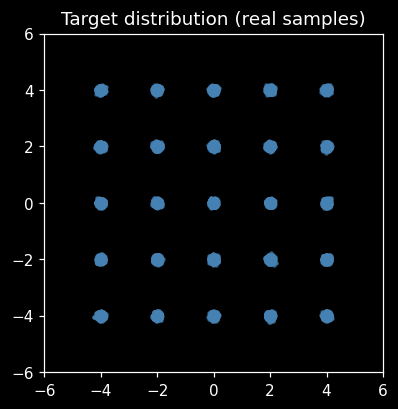

In [41]:
GRID_SIZE = 5
SPACING   = 2.0          # grid step; modes span [-4, 4] in each axis
N_MODES   = GRID_SIZE ** 2   # 25
MODE_STD  = 0.05         # tight blobs — dropped modes are immediately visible

_xs = np.linspace(-(GRID_SIZE // 2) * SPACING, (GRID_SIZE // 2) * SPACING, GRID_SIZE)
_centers = np.array([(x, y) for y in _xs for x in _xs], dtype=np.float32)   # row-major

def sample_real(n: int) -> torch.Tensor:
    idx = np.random.randint(0, N_MODES, size=n)
    pts = _centers[idx] + MODE_STD * np.random.randn(n, 2).astype(np.float32)
    return torch.from_numpy(pts).to(device)

real_demo = sample_real(100000).cpu().numpy()
plt.figure(figsize=(4, 4))
plt.scatter(real_demo[:, 0], real_demo[:, 1], s=4, c='steelblue', alpha=0.6)
plt.gca().set_aspect('equal'); plt.title('Target distribution (real samples)')
plt.xlim(-6, 6); plt.ylim(-6, 6); plt.show()

## Architectures

For 2D data, small MLPs are plenty. Same backbone for $G$ and $D$; only the output dim and final activation differ.

Two design choices to flag:
- **Generator input dim** ($Z\_\text{dim}=16$). Larger than the data dim — the generator has extra latent degrees of freedom to route samples to different modes.
- **Discriminator output activation.** Vanilla GAN ends in `sigmoid` (output is a probability). WGAN-GP critic outputs an *unbounded scalar*.

In [42]:
Z_DIM  = 16
HIDDEN = 128

def mlp(in_dim, out_dim, hidden=HIDDEN, n_layers=3, last_activation=None):
    layers = [nn.Linear(in_dim, hidden), nn.LeakyReLU(0.2)]
    for _ in range(n_layers - 2):
        layers += [nn.Linear(hidden, hidden), nn.LeakyReLU(0.2)]
    layers += [nn.Linear(hidden, out_dim)]
    if last_activation is not None:
        layers += [last_activation]
    return nn.Sequential(*layers)

# Sigmoid on D: output is a probability of "real".
def make_vanilla_gan():
    G = mlp(Z_DIM, 2).to(device)
    D = mlp(2, 1, last_activation=nn.Sigmoid()).to(device)
    return G, D

# No final activation: critic outputs an unbounded score.
def make_wgan():
    G = mlp(Z_DIM, 2).to(device)
    D = mlp(2, 1).to(device)
    return G, D

## A diagnostic plot we will reuse

At every snapshot we plot, on the same axes:
- the **discriminator/critic output** as a heatmap over a 2D grid (this is the network's "opinion" of every point in the plane),
- a sample of **real points** (blue),
- a sample of **generated points** (orange).

Reading this plot is the single most useful skill for debugging a GAN. Watch how the heatmap evolves.

In [70]:
@torch.no_grad()
def plot_snapshot(ax, G, D, title, grid_lim=6.0, n_grid=80, n_pts=800,
                  score_label='Discriminator Value', low_label='Fake', high_label='Real'):
    xs = np.linspace(-grid_lim, grid_lim, n_grid)
    XX, YY = np.meshgrid(xs, xs)
    grid = torch.from_numpy(np.stack([XX.ravel(), YY.ravel()], 1).astype(np.float32)).to(device)
    d_grid = D(grid).cpu().numpy().reshape(n_grid, n_grid)

    cf = ax.contourf(XX, YY, d_grid, levels=25, cmap='RdBu_r')

    real = sample_real(n_pts).cpu().numpy()
    z = torch.randn(n_pts, Z_DIM, device=device)
    fake = G(z).cpu().numpy()

    ax.scatter(real[:, 0], real[:, 1], s=3, c='royalblue', alpha=0.5, label='real')
    ax.scatter(fake[:, 0], fake[:, 1], s=3, c='darkorange', alpha=0.7, label='fake')
    ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

    cbar = ax.get_figure().colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(score_label, fontsize=8)
    cbar.ax.text(0.5, -0.02, low_label, transform=cbar.ax.transAxes,
                 ha='center', va='top', fontsize=7, color='gray')
    cbar.ax.text(0.5, 1.02, high_label, transform=cbar.ax.transAxes,
                 ha='center', va='bottom', fontsize=7, color='gray')

    return cf

## 1. Vanilla GAN

**Discriminator loss** (binary cross-entropy):
$$\mathcal{L}_D = -\mathbb{E}[\log D(x)] - \mathbb{E}[\log(1 - D(G(z)))].$$

**Generator loss** — we use the *non-saturating* form (Goodfellow's own trick):
$$\mathcal{L}_G = -\mathbb{E}[\log D(G(z))].$$

The original $\log(1 - D(G(z)))$ has vanishing gradients exactly when $G$ is doing badly — counter-productive. Flipping the label ("pretend the fakes are real") gives a steeper signal early on.

**Training schedule.** Alternate one $D$ step and one $G$ step. Adam optimizers with $\beta_1=0.5$ — this lower momentum is folklore-but-it-works for GANs.

In [44]:
def _clone(net):
    return copy.deepcopy(net).eval()

def train_vanilla_gan(n_iters=4000, batch=8096, lr=2e-4, snapshots=()):
    G, D = make_vanilla_gan()
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    history = {'d_loss': [], 'g_loss': []}
    snaps = {0: (_clone(G), _clone(D))} if 0 in snapshots else {}

    for it in trange(1, n_iters + 1, desc='vanilla GAN'):
        # ---- D step: push D(real) → 1, D(fake) → 0 ----
        x_real = sample_real(batch)
        z = torch.randn(batch, Z_DIM, device=device)
        x_fake = G(z).detach()          # detach so D's gradients don't flow into G
        d_real = D(x_real)
        d_fake = D(x_fake)
        d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        # ---- G step (non-saturating): push D(fake) → 1 ----
        z = torch.randn(batch, Z_DIM, device=device)
        d_fake_g = D(G(z))
        g_loss = bce(d_fake_g, torch.ones_like(d_fake_g))
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        history['d_loss'].append(d_loss.item())
        history['g_loss'].append(g_loss.item())
        if it in snapshots:
            snaps[it] = (_clone(G), _clone(D))
    return G, D, history, snaps

In [45]:
torch.manual_seed(42); np.random.seed(42)
snapshots_v = (0, 200, 1000, 5000, 20000, 100_000)
G_v, D_v, hist_v, snaps_v = train_vanilla_gan(n_iters=100_000, snapshots=snapshots_v)

vanilla GAN:   0%|          | 0/100000 [00:00<?, ?it/s]

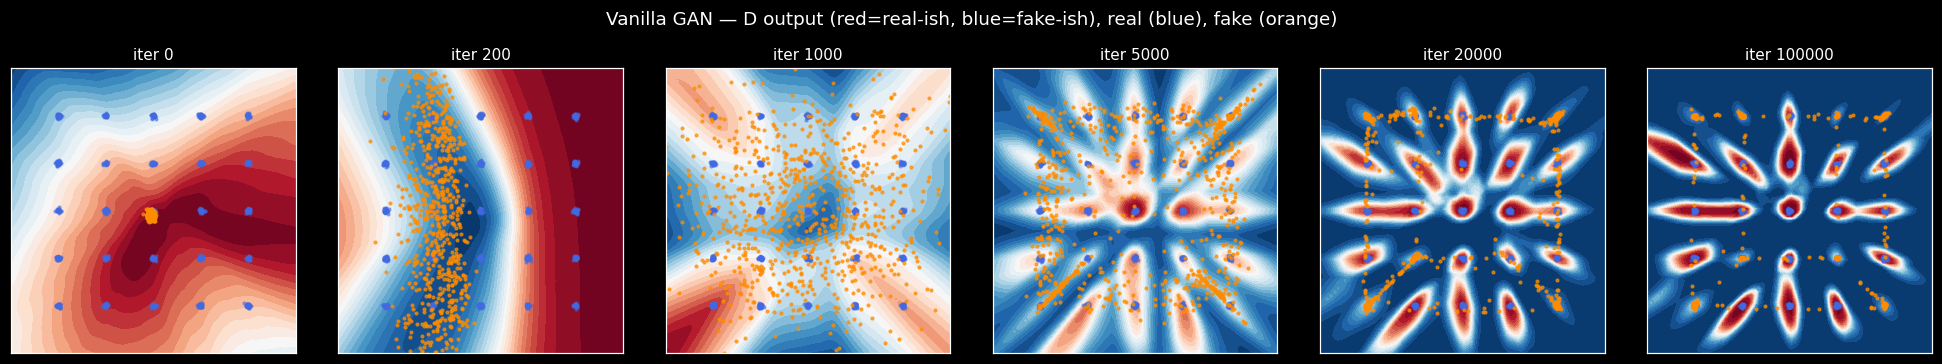

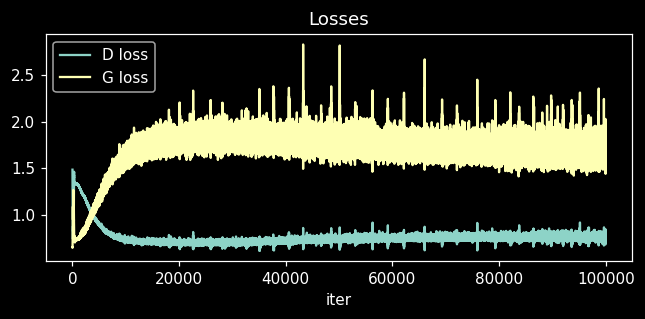

In [46]:
fig, axes = plt.subplots(1, len(snapshots_v), figsize=(3 * len(snapshots_v), 3.2))
for ax, it in zip(axes, snapshots_v):
    G_s, D_s = snaps_v[it]
    plot_snapshot(ax, G_s, D_s, title=f'iter {it}')
fig.suptitle('Vanilla GAN — D output (red=real-ish, blue=fake-ish), real (blue), fake (orange)', y=1.02)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(hist_v['d_loss'], label='D loss')
ax.plot(hist_v['g_loss'], label='G loss')
ax.set_xlabel('iter'); ax.set_title('Losses'); ax.legend()
plt.tight_layout(); plt.show()

### What just happened?

Look at the snapshot heatmaps left-to-right. Two things evolve:

1. **Discriminator saturation.** Early on the heatmap is a smooth gradient — $G$ gets a strong directional signal and spreads quickly. But as $D$ wins, the heatmap freezes into a near step-function: $D(x)\approx 1$ near real samples, $D(x)\approx 0$ everywhere else. Once $D$ is that confident, $\nabla_x \log D(x)\to 0$ almost everywhere and **$G$ has no gradient to learn from**.

2. **Mode imbalance gets worse over time.** In the very first snapshots the orange dots are spread reasonably across the grid. Then the discriminator saturates — and because the gradient signal dies, $G$ can no longer correct its sampling: modes that happen to attract more samples keep them, while underrepresented modes are forgotten. The max/min ratio *increases* as training continues.

Both trace to the same root cause: the BCE objective corresponds to the Jensen-Shannon divergence, and JS is *not continuous* in $G$'s parameters when the real and fake supports are disjoint — which is exactly the situation when modes are tight Gaussians and $G$ covers only some of them. Once $D$ perfectly separates the distributions, the game's gradient signals vanish.

## 2. Wasserstein GAN with Gradient Penalty

**Idea.** Replace the JS-flavored objective with the **Wasserstein-1 distance** between $p_{\text{data}}$ and $p_G$:
$$W_1(p_{\text{data}}, p_G) = \sup_{\|f\|_L \le 1} \; \mathbb{E}_{x\sim p_{\text{data}}}[f(x)] - \mathbb{E}_{x\sim p_G}[f(x)].$$

The supremum is over **1-Lipschitz** functions $f$. We let the critic $D_\phi$ be that $f$:
$$\mathcal{L}_D = -\mathbb{E}[D(x)] + \mathbb{E}[D(G(z))], \qquad \mathcal{L}_G = -\mathbb{E}[D(G(z))].$$

$D$ now outputs an unbounded *score*, not a probability. As long as the critic stays Lipschitz, gradients with respect to $G$ remain informative even when distributions don't overlap — which is the whole point.

**Enforcing Lipschitz.** WGAN-GP adds a penalty pushing the gradient norm of the critic, evaluated at random interpolations $\hat{x} = \epsilon x + (1-\epsilon) G(z)$, toward 1:
$$\mathcal{L}_{\text{GP}} = \lambda \, \mathbb{E}_{\hat{x}}\big[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2\big].$$
Typically $\lambda=10$, and the critic is trained $n_{\text{critic}}\approx 5$ steps per generator step so it stays close to the optimum.

In [47]:
def gradient_penalty(D, x_real, x_fake):
    """GP: E[(‖∇D(x̂)‖₂ - 1)²] on random interpolations x̂ = εx + (1-ε)G(z)."""
    eps = torch.rand(x_real.size(0), 1, device=device)
    x_hat = (eps * x_real + (1 - eps) * x_fake).requires_grad_(True)
    d_hat = D(x_hat)
    # create_graph=True keeps the graph so second-order grads flow back through the penalty.
    grads = torch.autograd.grad(d_hat.sum(), x_hat, create_graph=True)[0]
    norms = grads.norm(2, dim=1)
    return ((norms - 1) ** 2).mean(), norms.detach().mean().item()

def train_wgan_gp(n_iters=10000, batch=8096, lr=1e-4, n_critic=5, lam=10.0, snapshots=()):
    G, D = make_wgan()
    # β1=0, β2=0.9: paper §4 recommendation for stable critic training.
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))

    history = {'d_loss': [], 'g_loss': [], 'w_est': [], 'grad_norm': []}
    snaps = {0: (_clone(G), _clone(D))} if 0 in snapshots else {}

    for it in trange(1, n_iters + 1, desc='WGAN-GP'):
        # ---- n_critic critic steps ----
        for _ in range(n_critic):
            x_real = sample_real(batch)
            z = torch.randn(batch, Z_DIM, device=device)
            x_fake = G(z).detach()
            d_real = D(x_real).mean()
            d_fake = D(x_fake).mean()
            gp, gn = gradient_penalty(D, x_real, x_fake)
            d_loss = -(d_real - d_fake) + lam * gp
            opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        # ---- one generator step ----
        z = torch.randn(batch, Z_DIM, device=device)
        g_loss = -D(G(z)).mean()
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        history['d_loss'].append(d_loss.item())
        history['g_loss'].append(g_loss.item())
        history['w_est'].append((d_real - d_fake).item())
        history['grad_norm'].append(gn)
        if it in snapshots:
            snaps[it] = (_clone(G), _clone(D))
    return G, D, history, snaps

In [48]:
torch.manual_seed(42); np.random.seed(42)
snapshots_w = (0, 200, 1000, 5000, 20000, 100_000)
G_w, D_w, hist_w, snaps_w = train_wgan_gp(n_iters=100_000, snapshots=snapshots_w)

WGAN-GP:   0%|          | 0/100000 [00:00<?, ?it/s]

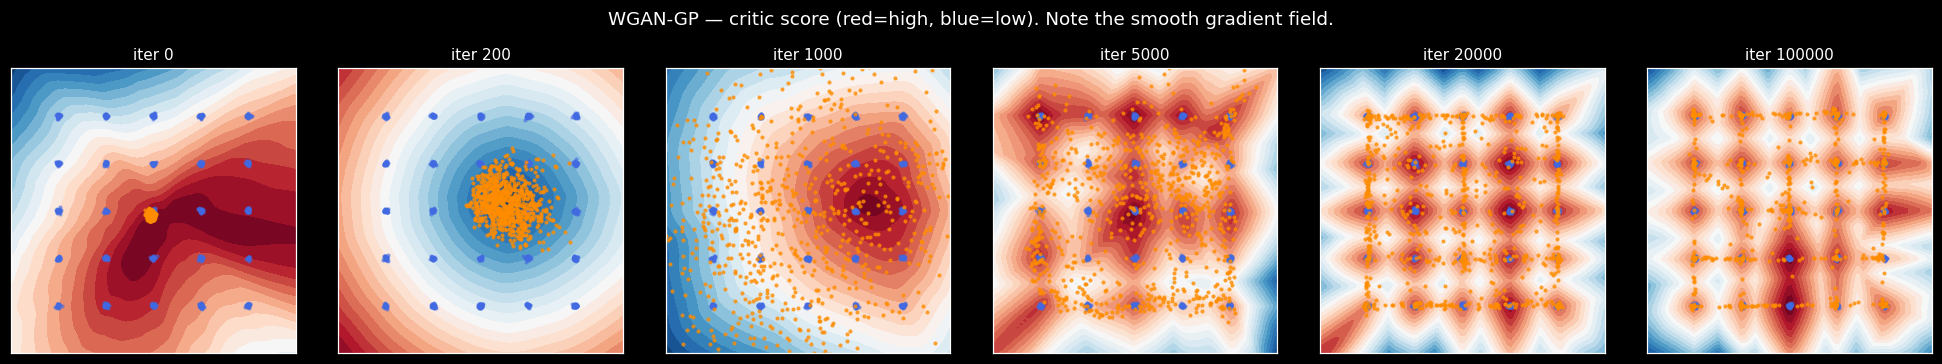

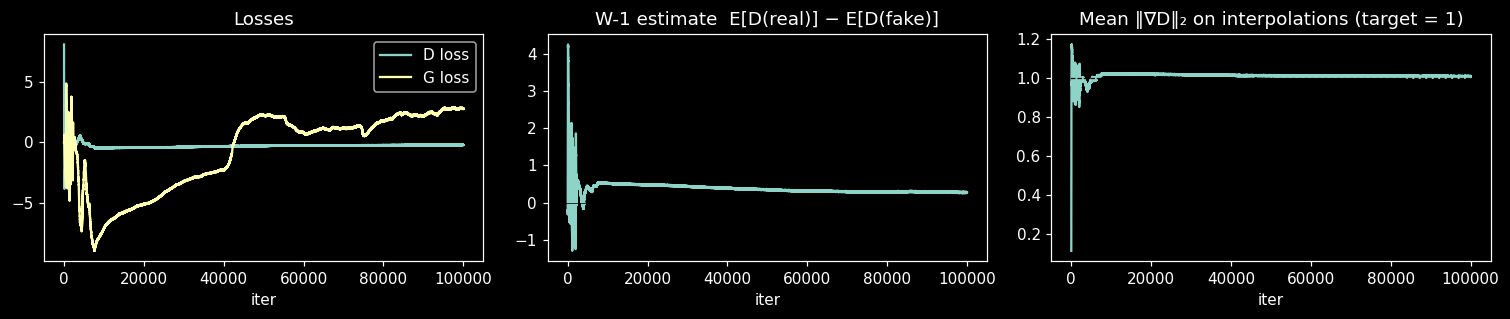

In [49]:
fig, axes = plt.subplots(1, len(snapshots_w), figsize=(3 * len(snapshots_w), 3.2))
for ax, it in zip(axes, snapshots_w):
    G_s, D_s = snaps_w[it]
    plot_snapshot(ax, G_s, D_s, title=f'iter {it}')
fig.suptitle('WGAN-GP — critic score (red=high, blue=low). Note the smooth gradient field.', y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(hist_w['d_loss'], label='D loss'); axes[0].plot(hist_w['g_loss'], label='G loss')
axes[0].set_xlabel('iter'); axes[0].set_title('Losses'); axes[0].legend()
axes[1].plot(hist_w['w_est']); axes[1].set_xlabel('iter')
axes[1].set_title('W-1 estimate  E[D(real)] − E[D(fake)]'); axes[1].axhline(0, color='k', lw=0.5)
axes[2].plot(hist_w['grad_norm']); axes[2].axhline(1, color='k', lw=0.8, ls='--')
axes[2].set_xlabel('iter'); axes[2].set_title('Mean ‖∇D‖₂ on interpolations (target = 1)')
plt.tight_layout(); plt.show()

### What's different now?

1. **Smooth heatmaps.** The critic's output is no longer a saturated step. Its **gradient** ∇D(x) — the actual signal $G$ optimizes against — is well-defined everywhere, pointing away from fake clusters and toward real ones. This is directly enforced by the gradient penalty keeping ‖∇D‖ ≈ 1 (check the fourth loss panel).
2. **All 25 modes covered.** The Wasserstein objective penalizes mass-transport distance, so dropping a mode incurs a real cost — the critic keeps widening the gap until the generator visits it. Vanilla GAN can satisfy its objective while ignoring entire regions of the real distribution.
3. **The W-estimate is a useful loss curve.** Unlike vanilla GAN losses (which are uninterpretable numbers), $\mathbb{E}[D(x)]-\mathbb{E}[D(G(z))]$ estimates the Wasserstein-1 distance and correlates with sample quality. Watch it decrease as the generator improves.
4. **Gradient norm ≈ 1 confirms the penalty is working.** If you set `lam=0`, this will drift far from 1 and training will destabilize.

## Side-by-side comparison

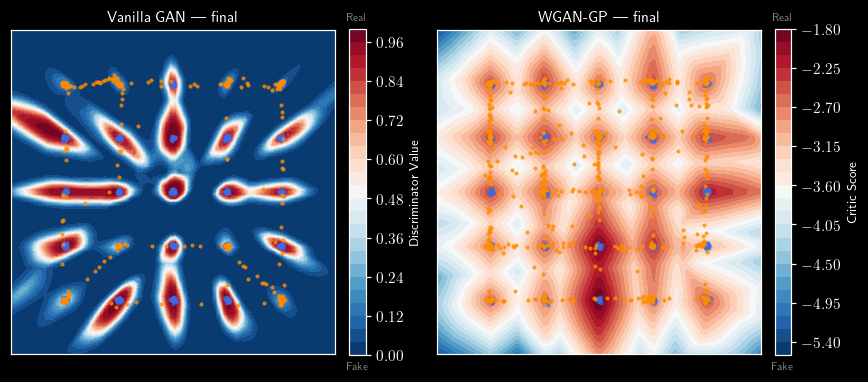

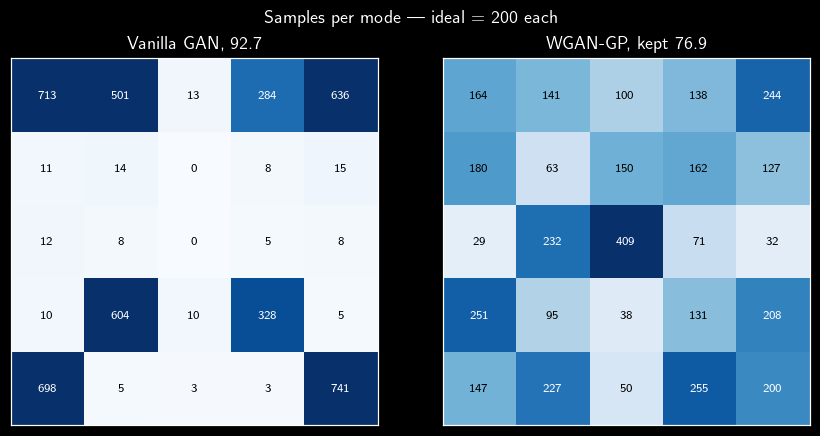

In [71]:
plt.rcParams['text.usetex'] = True

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_snapshot(axes[0], G_v, D_v, 'Vanilla GAN — final',
              score_label='Discriminator Value', low_label='Fake', high_label='Real')

plot_snapshot(axes[1], G_w, D_w, 'WGAN-GP — final',
              score_label='Critic Score', low_label='Fake', high_label='Real')
plt.tight_layout(); plt.show()

@torch.no_grad()
def mode_counts(G, n=5000):
    z = torch.randn(n, Z_DIM, device=device)
    fake = G(z).cpu().numpy()
    d2 = ((fake[:, None, :] - _centers[None, :, :]) ** 2).sum(-1)
    nearest_d = d2.min(1)
    mask = nearest_d < (10 * MODE_STD) ** 2
    bins = np.bincount(d2[mask].argmin(1), minlength=N_MODES)
    pct  = mask.mean() * 100
    return bins, pct

cv, pct_v = mode_counts(G_v)
cw, pct_w = mode_counts(G_w)

def plot_coverage_grid(ax, counts, title):
    ideal = counts.sum() // N_MODES
    grid = counts.reshape(GRID_SIZE, GRID_SIZE)
    ax.imshow(grid, cmap='Blues', vmin=0, vmax=ideal * 2, origin='lower')
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            ax.text(j, i, grid[i, j], ha='center', va='center', fontsize=8,
                    color='white' if grid[i, j] > ideal * 1.2 else 'black')
    ratio = counts.max() / max(counts.min(), 1)
    ax.set_title(f'{title}  (max/min = {ratio:.0f}×)'); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_coverage_grid(axes[0], cv, f'Vanilla GAN, {pct_v:.1f}%' +  r' within $5\sigma$')
plot_coverage_grid(axes[1], cw, f'WGAN-GP, kept {pct_w:.1f}%' +  r' within $5\sigma$')
plt.suptitle(f'Samples per mode — ideal = {5000 // N_MODES} each')
plt.tight_layout()
plt.show()

In [81]:
@torch.no_grad()
def plot_snapshot_3d(ax, G, D, title, grid_lim=6.0, n_grid=60, n_pts=400,
                     score_label='Discriminator Value'):
    # --- surface ---
    xs = np.linspace(-grid_lim, grid_lim, n_grid)
    XX, YY = np.meshgrid(xs, xs)
    grid = torch.from_numpy(
        np.stack([XX.ravel(), YY.ravel()], 1).astype(np.float32)
    ).to(device)
    ZZ = D(grid).cpu().numpy().reshape(n_grid, n_grid)

    ax.plot_surface(XX, YY, ZZ, cmap='RdBu_r', alpha=0.85,
                    linewidth=0, antialiased=True, zorder=1)

    # --- real points: query D to get their z-height ---
    real = sample_real(n_pts).cpu().numpy()
    real_t = torch.from_numpy(real.astype(np.float32)).to(device)
    real_z = D(real_t).cpu().numpy().ravel()

    # --- fake points ---
    z = torch.randn(n_pts, Z_DIM, device=device)
    fake = G(z).cpu().numpy()
    fake_t = torch.from_numpy(fake.astype(np.float32)).to(device)
    fake_z = D(fake_t).cpu().numpy().ravel()

    ax.scatter(real[:, 0], real[:, 1], real_z,
               s=6, c='royalblue', alpha=0.7, zorder=5, label='real',
               depthshade=True)

    ax.set_xlim(-grid_lim, grid_lim)
    ax.set_ylim(-grid_lim, grid_lim)
    ax.set_xlabel('$x_1$', fontsize=8, labelpad=2)
    ax.set_ylabel('$x_2$', fontsize=8, labelpad=2)
    ax.set_zlabel(score_label, fontsize=8, labelpad=2)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=7, loc='upper left', markerscale=2)

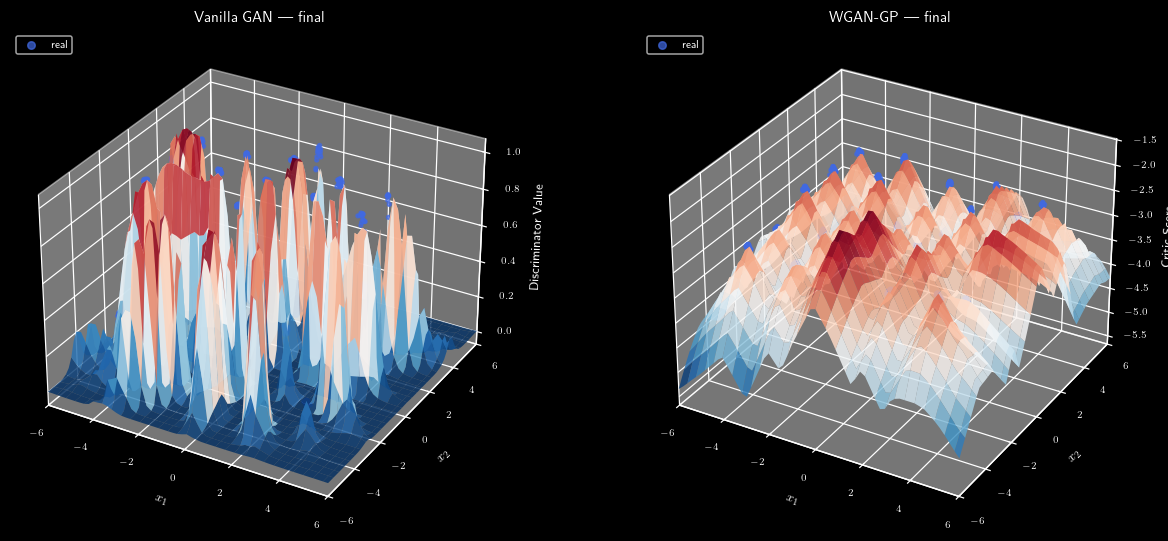

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          subplot_kw={'projection': '3d'})
plot_snapshot_3d(axes[0], G_v, D_v, 'Vanilla GAN — final',
                 score_label='Discriminator Value')
plot_snapshot_3d(axes[1], G_w, D_w, 'WGAN-GP — final',
                 score_label='Critic Score')

plt.tight_layout()
plt.show()

In [51]:
def mmd(X: torch.Tensor, Y: torch.Tensor, sigma: float = 1.0) -> float:
    """Unbiased RBF-kernel MMD. Lower = more similar; 0 = identical distributions."""
    def rbf(A, B):
        return torch.exp(-torch.cdist(A, B) ** 2 / (2 * sigma ** 2))

    n, m = len(X), len(Y)
    Kxx = rbf(X, X); Kxx.fill_diagonal_(0)
    Kyy = rbf(Y, Y); Kyy.fill_diagonal_(0)
    Kxy = rbf(X, Y)
    return (Kxx.sum()/(n*(n-1)) + Kyy.sum()/(m*(m-1)) - 2*Kxy.sum()/(n*m)).sqrt().item()

<img height="300" src="img.png" width="900"/>

In [52]:
B = 4096
true      = sample_real(B)
samples_v = G_v(torch.randn(B, Z_DIM, device=device))
samples_w = G_w(torch.randn(B, Z_DIM, device=device))

print(f"Vanilla GAN  MMD: {mmd(samples_v, true):.4f}")
print(f"WGAN-GP      MMD: {mmd(samples_w, true):.4f}")

Vanilla GAN  MMD: 0.2812
WGAN-GP      MMD: 0.0917
